## Implementacja kd-drzewa (kd-tree)

In [165]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parents[0]))

In [166]:
from visualizer.main import Visualizer
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

Funkcje pomocnicze służące do wczytywania zbioru punktów za pomocą myszki.

In [167]:
%matplotlib tk

events = []
points = []
active = True

def draw_point(point) -> None:
    plt.scatter(point[0], point[1], color="red")
    plt.show()
    
def onclick(event) -> None:
    global active
    if event.button == 1 and active:
        x, y = event.xdata, event.ydata
        new_point = (x, y)
        points.append(new_point)
        draw_point(new_point)
    elif event.button == 3:
        active = False
        plt.pause(1)
        plt.close()
        
fig, ax = plt.subplots()
plt.get_current_fig_manager().set_window_title("Umieszczanie punktów na płaszczyźnie")
ax.set_title("LPM: Dodanie punktu\nPPM: Zakończenie")
connection_id = fig.canvas.mpl_connect("button_press_event", onclick)
ax.set_xlim([0, 10])
ax.set_ylim([0, 10])
plt.tight_layout()
plt.ion()
plt.show()  

[(np.float64(2.9680636065494417), np.float64(3.4263260157178888)), (np.float64(5.674972468626335), np.float64(5.2011135922048535)), (np.float64(3.165563394769644), np.float64(7.689296174926773)), (np.float64(5.036002565560974), np.float64(6.92370153408926)), (np.float64(3.444386625198165), np.float64(4.71391700258098)), (np.float64(7.417617658804593), np.float64(5.792709451033842)), (np.float64(4.455120835501555), np.float64(8.541890206768551)), (np.float64(4.501591373906308), np.float64(6.419105066264534)), (np.float64(6.174530756477436), np.float64(6.958501290490965)), (np.float64(6.209383660281001), np.float64(4.626917611576718)), (np.float64(7.034235716965377), np.float64(7.428298001913984)), (np.float64(5.291590526787119), np.float64(8.367891424760026)), (np.float64(5.396149238197814), np.float64(6.506104457268798)), (np.float64(4.85012041194196), np.float64(5.2011135922048535)), (np.float64(4.036885989858773), np.float64(7.062900559696081)), (np.float64(4.85012041194196), np.floa

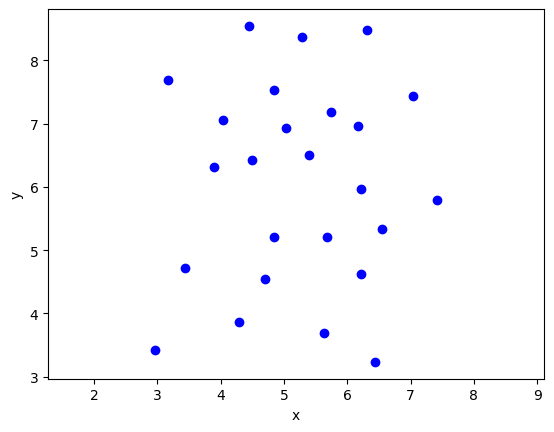

In [186]:
%matplotlib inline
print(points)
vis = Visualizer()
vis.axis_equal()
vis.add_point(points, color="blue")
vis.show()

Funkcje pomocnicze do wczytywania zakresów obszaru za pomocą myszki.

In [169]:
%matplotlib tk

range_points = []

def draw_point(point):
    plt.scatter(point[0], point[1], color="red")
    plt.draw()
    
def onclick(event):
    global range_points

    if event.button == 1 and len(range_points) < 2:
        x, y = event.xdata, event.ydata
        if x is None or y is None:
            return

        new_point = (x, y)
        range_points.append(new_point)

        if len(range_points) == 2:
            plt.pause(1)
            plt.close()

fig, ax = plt.subplots()
plt.get_current_fig_manager().set_window_title("Wybieranie obszaru zapytania")
ax.set_title("1: lewy dolny róg\n2: prawy górny róg")
ax.set_xlim([0, 10])
ax.set_ylim([0, 10])

xs = [p[0] for p in points]
ys = [p[1] for p in points]
ax.scatter(xs, ys, color="red")

fig.canvas.mpl_connect("button_press_event", onclick)
plt.ion()
plt.show()


In [170]:
query_region = range_points[0][0], range_points[1][0], range_points[0][1], range_points[1][1]
print(query_region)

(np.float64(4.274193548387097), np.float64(6.263440860215055), np.float64(5.371572871572872), np.float64(7.806637806637807))


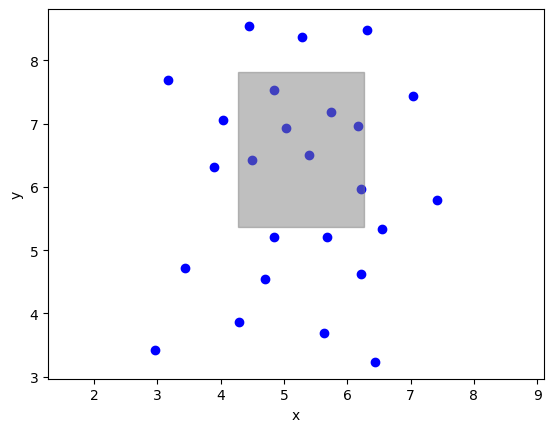

In [185]:
%matplotlib inline
vis = Visualizer()
vis.axis_equal()
vis.add_point(points, color="blue")

xmin, xmax, ymin, ymax = query_region
vis.add_polygon(((xmin, ymin), (xmin, ymax), (xmax, ymax), (xmax, ymin)), alpha = 0.5, color="grey")

vis.show()

Implementacja kd-drzew (kd-tree).

In [171]:
class Node:
    def __init__(self, point, axis = 0, left = None, right = None):
        self.point = point
        self.axis = axis
        self.left = left
        self.right = right
        
    def get_subtree_points(self):
        points = [self.point]

        if self.left is not None:
            points += self.left.get_subtree_points()
        if self.right is not None:
            points += self.right.get_subtree_points()
            
        return points

    def __repr__(self):
        return f"({self.point[0]}, {self.point[1]}), {'x' if self.axis == 0 else 'y'}"
    
class Kdtree:
    def build_kdtree(self, points, depth = 0):
        axis = depth % self.k
        n = len(points[axis])
        
        if n < 1:
            return None
        if n == 1:
            return Node(points[axis][0], axis = depth % self.k)
        
        median = points[axis][n // 2]
        
        left, right = [[] for _ in range(self.k)], [[] for _ in range(self.k)]
        
        for i in range(self.k):
            for p in points[i]:
                if p == median:
                    continue
                if p[axis] < median[axis]:
                    left[i].append(p)
                else:
                    right[i].append(p)
        
        return Node(
            point = median,
            axis = axis,
            left = self.build_kdtree(left, depth + 1),
            right = self.build_kdtree(right, depth + 1)
        )
        
    def __init__(self, points, k = 2):
        self.points = points
        self.k = k
        
        P = [sorted(points, key = lambda x: x[i]) for i in range(k)]
        
        self.root = self.build_kdtree(P)
    
    def contains(self, node_region, query_region):
        x1, x2, y1, y2 = node_region
        xmin, xmax, ymin, ymax = query_region
        return xmin <= x1 and x2 <= xmax and ymin <= y1 and y2 <= ymax
        
    def intersects(self, node_region, query_region):
        x1, x2, y1, y2 = node_region
        xmin, xmax, ymin, ymax = query_region
        return not (xmin > x2 or x1 > xmax or ymin > y2 or y1 > ymax)
       
    def search(self, node: Node, node_region, query_region, result):
        if not node:
            return
        
        x1, x2, y1, y2 = node_region
        xmin, xmax, ymin, ymax = query_region
        x, y = node.point
        
        if xmin <= x <= xmax and ymin <= y <= ymax:
            result.append(node.point)
            
        if node.axis == 0:
            left_region = [x1, x, y1, y2]
            right_region = [x, x2, y1, y2]
        else:
            left_region = [x1, x2, y1, y]
            right_region = [x1, x2, y, y2]
                        
        if node.left:  
            if self.contains(left_region, query_region):
                result.extend(node.left.get_subtree_points())
            elif self.intersects(left_region, query_region):
                self.search(node.left, left_region, query_region, result)
        
        if node.right:
            if self.contains(right_region, query_region):
                result.extend(node.right.get_subtree_points())
            elif self.intersects(right_region, query_region):
                self.search(node.right, right_region, query_region, result)
                
    def search_vis(self, node: Node, node_region, query_region, result, vis: Visualizer):
        if not node:
            return
        
        x1, x2, y1, y2 = node_region
        xmin, xmax, ymin, ymax = query_region
        x, y = node.point
        

        to_remove = []
        
        area = [(x1, y1), (x1, y2), (x2, y2), (x2, y1)]
        to_remove.append(vis.add_polygon(area, alpha = 0.3, color="grey"))
        
        to_remove.append(vis.add_point(node.point, color="orange"))
        
        if node.axis == 0:
            to_remove.append(vis.add_line_segment(((x, y1), (x, y2)), color="yellow"))
        else:
            to_remove.append(vis.add_line_segment(((x1, y), (x2, y)), color="yellow"))
        
        for fig in to_remove:
            vis.remove_figure(fig)
        
        if xmin <= x <= xmax and ymin <= y <= ymax:
            result.append(node.point)
            vis.add_point(node.point, color="red")
            
        if node.axis == 0:
            left_region = [x1, x, y1, y2]
            right_region = [x, x2, y1, y2]
        else:
            left_region = [x1, x2, y1, y]
            right_region = [x1, x2, y, y2]
                        
        if node.left:  
            if self.contains(left_region, query_region):
                pts = node.left.get_subtree_points()
                result.extend(pts)
                for p in pts:
                    vis.add_point(p, color="red")
            elif self.intersects(left_region, query_region):
                self.search_vis(node.left, left_region, query_region, result, vis)
        
        if node.right:
            if self.contains(right_region, query_region):
                pts = node.right.get_subtree_points()
                result.extend(pts)
                for p in pts:
                    vis.add_point(p, color="red")
            elif self.intersects(right_region, query_region):
                self.search_vis(node.right, right_region, query_region, result, vis)

Testy budowania drzewa.

In [ ]:
# kdtree building tests

Przykładowy zbiór punktów oraz granice zapytania.

In [ ]:
# points = [(5, 5), (3, 7), (6, 3), (8, 8), (9, 9), (2, 3), (10, 1)]
# query_region = (1, 8, 1, 6)

Wizualizacja kd-drzewa (kd-tree).

In [172]:
def traverse(root: Node, vis: Visualizer, xmin = 0, xmax = 10, ymin = 0, ymax = 10) -> None:
    area = [(xmin, ymin), (xmin, ymax), (xmax, ymax), (xmax, ymin)]
    to_remove = vis.add_polygon(area, alpha = 0.3, color="grey")
    vis.remove_figure(to_remove)
    
    if not root:
        return

    x, y = root.point
    
    if root.axis == 0:
        vis.add_line_segment(((x, ymin), (x, ymax)), color="green")
        
        traverse(root.left, vis, xmin, x, ymin, ymax)
        traverse(root.right, vis, x, xmax, ymin, ymax)
        
    else:
        vis.add_line_segment(((xmin, y), (xmax, y)), color="green")
        
        traverse(root.left, vis, xmin, xmax, ymin, y)
        traverse(root.right, vis, xmin, xmax, y, ymax)
        

def kdtree_vis(kdtree: Kdtree) -> Visualizer:
    vis = Visualizer()
    
    vis.add_point(kdtree.points, color="blue")
    
    root = kdtree.root
    
    traverse(root, vis)
    
    return vis

In [173]:
kdtree = Kdtree(points)
default_region = (0, 10, 0, 10)

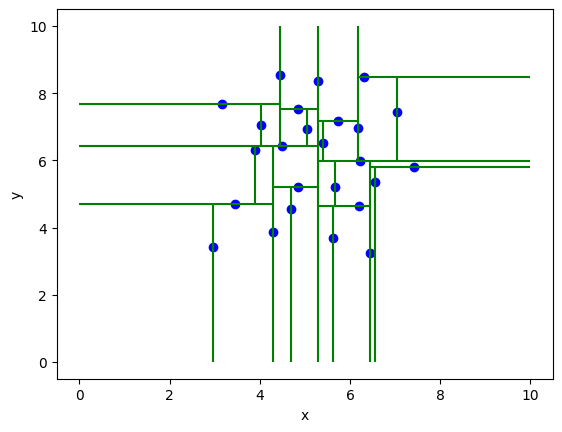

In [174]:
%matplotlib inline
vis = kdtree_vis(kdtree)
vis.show()

Wizualizacja poszczególnych kroków budowania drzewa.

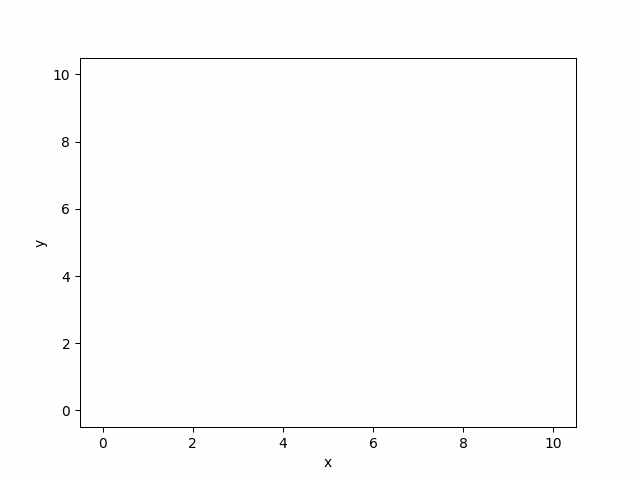

In [175]:
%matplotlib inline
vis.show_gif()

Znajdowanie punktów należących do zadanego obszaru w kształcie prostokąta.

In [176]:
def search(kdtree: Kdtree, query_region, node_region):
    result = []
    kdtree.search(kdtree.root, node_region, query_region, result)
    return result

In [177]:
result = search(kdtree, query_region, default_region)
print(result)

[(np.float64(4.501591373906308), np.float64(6.419105066264534)), (np.float64(4.85012041194196), np.float64(7.5326972711191)), (np.float64(5.036002565560974), np.float64(6.92370153408926)), (np.float64(6.22100129488219), np.float64(5.966708233042367)), (np.float64(6.174530756477436), np.float64(6.958501290490965)), (np.float64(5.744678276233466), np.float64(7.184699707102049)), (np.float64(5.396149238197814), np.float64(6.506104457268798))]


Testy działania zapytania.

In [ ]:
# query tests

Wizualizacja zbioru punktów należących do zadanego regionu.

In [178]:
def search_vis(kdtree: Kdtree, query_region, node_region):
    result = []
    vis = kdtree_vis(kdtree)
    xmin, xmax, ymin, ymax = query_region
    vis.add_polygon(((xmin, ymin), (xmin, ymax), (xmax, ymax), (xmax, ymin)), alpha = 0.5, color="grey")
    kdtree.search_vis(kdtree.root, node_region, query_region, result, vis)
    return vis

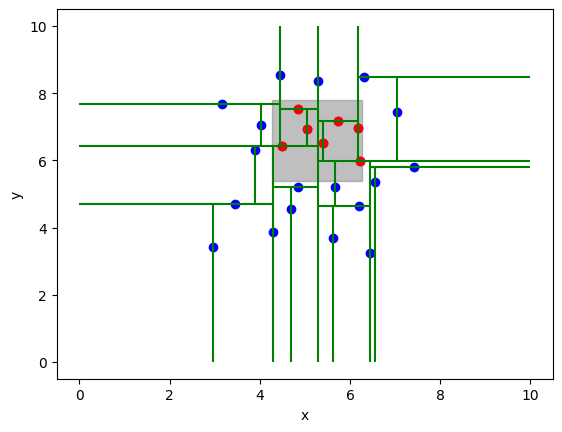

In [179]:
%matplotlib inline
vis = search_vis(kdtree, query_region, default_region)
vis.show()

Wizualizacja poszczególnych kroków szukania punktów należących do zadanego regionu.

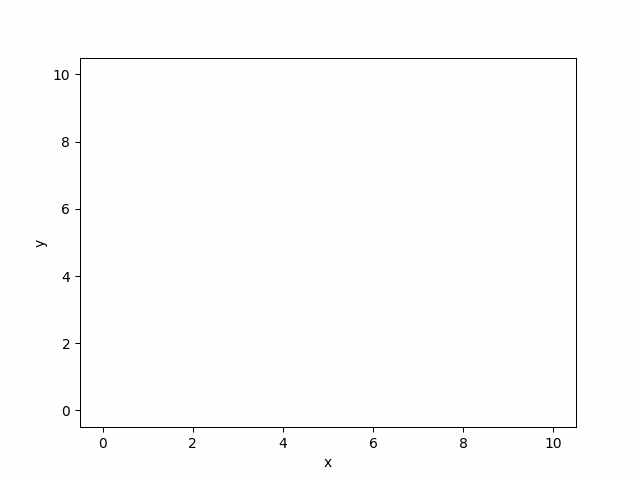

In [180]:
%matplotlib inline
vis.show_gif()

Poniżej znajdują się testy wydajnościowe.